# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina 
- _Student No._: 2024-09224
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Problem 1: (Newman 6.7) Resistor Ladder

![Voltage Distribution for Different Number of Nodes Problem 1](./Figures/e5.png)

*Figure 1: Voltage Distribution for Different Number of Nodes*

The resistor ladder was solved first for $N=6$ using a full matrix and then for $N=10{,}000$ using a banded matrix. For the larger system, the banded representation efficiently stores only the five nonzero diagonals, allowing the $10{,}000$-node system to be solved without constructing a large $10{,}000 \times 10{,}000$ matrix. The voltage distribution decreases from the first node toward the later nodes, showing how the applied voltage is distributed throughout the resistor ladder.

The comparison of $N=10$, $100$, $1000$, and $10{,}000$ shows that increasing the number of nodes produces a smoother and more gradually varying voltage distribution. The overall shape remains consistent, indicating that the banded-matrix method successfully handles increasingly large resistor networks while preserving the expected voltage behavior.

### Other comments
- It was nice figuring out how to code the matrices and learning how banded.py works. 


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

![reschain](./Figures/reschain.png)

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import banded as bd

In [2]:
# 3. N = 6

N = 6

# Construct matrix A
A = np.zeros((N,N))

for i in range(N):

    # Main Diagonal
    if i == 0 or i == N-1:
        A[i, i] = 3
    else:
        A[i, i] = 4

    # First off-diagonals
    if i-1 >= 0:
        A[i, i-1] = -1

    if i+1 < N:
        A[i, i+1] = -1

    # Second off-diagonals
    if i-2 >= 0:
        A[i, i-2] = -1

    if i+2 < N:
        A[i, i+2] = -1

# Construct matrix w
w = np.zeros(N)
w[0] = 5
w[1] = 5

# Solve Av = w
V = np.linalg.solve(A,w)

print("A =")
print(A)

print("\nw =")
print(w)

print("\nVoltages:")
for i in range(N):
    print(f"V{i+1} = {V[i]:.6f} V")

A =
[[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]

w =
[5. 5. 0. 0. 0. 0.]

Voltages:
V1 = 3.725490 V
V2 = 3.431373 V
V3 = 2.745098 V
V4 = 2.254902 V
V5 = 1.568627 V
V6 = 1.274510 V


In [3]:
# 4. N = 10 000

N = 10000

# Create the banded matrix
# 5 = 2 upper diagonals + main diagonal + 2 lower diagonals
A_bd = np.zeros((5, N))

# Main diagonal
A_bd[2, :] = 4
A_bd[2, 0] = 3
A_bd[2, N-1] = 3

# First upper diagonal
A_bd[1, 1:] = -1

# Second upper diagonal
A_bd[0, 2:] = -1

# First lower diagonal
A_bd[3, :-1] = -1

# Second lower diagonal
A_bd[4, :-2] = -1

# Right-hand side vector
w_bd = np.zeros(N)

w_bd[0] = 5
w_bd[1] = 5


# Solve A V = w
V_bd = bd.banded(A_bd, w_bd, 2, 2)


print("V1 =", V_bd[0])
print("V2 =", V_bd[1])
print("V3 =", V_bd[2])

print("VN-2 =", V_bd[N-3])
print("VN-1 =", V_bd[N-2])
print("VN =", V_bd[N-1])

print("Minimum voltage =", V_bd.min())
print("Maximum voltage =", V_bd.max())

V1 = 4.998882277727716
V2 = 4.998618419291493
V3 = 4.9980284138916575
VN-2 = 0.001971586108334918
VN-1 = 0.0013815807085025764
VN = 0.0011177222722791647
Minimum voltage = 0.0011177222722791647
Maximum voltage = 4.998882277727716


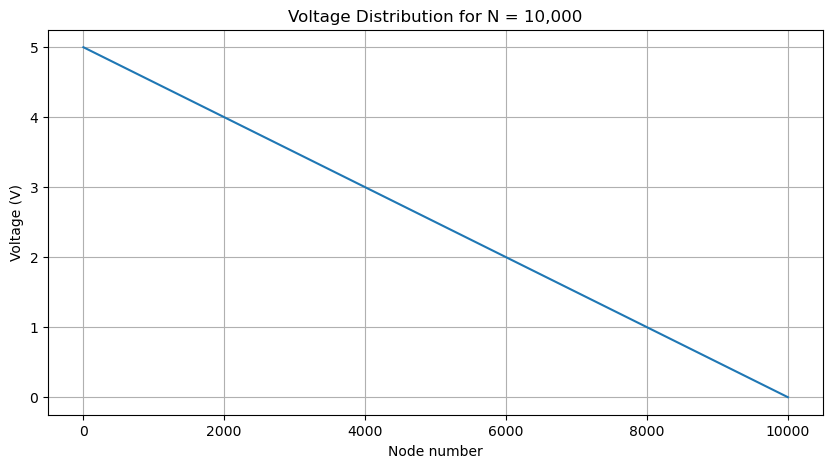

In [4]:
# Plot voltage for N = 10 000

nodes = np.arange(1, N+1)

plt.figure(figsize=(10,5))
plt.plot(nodes, V_bd)

plt.xlabel("Node number")
plt.ylabel("Voltage (V)")
plt.title("Voltage Distribution for N = 10,000")
plt.grid()

plt.show()

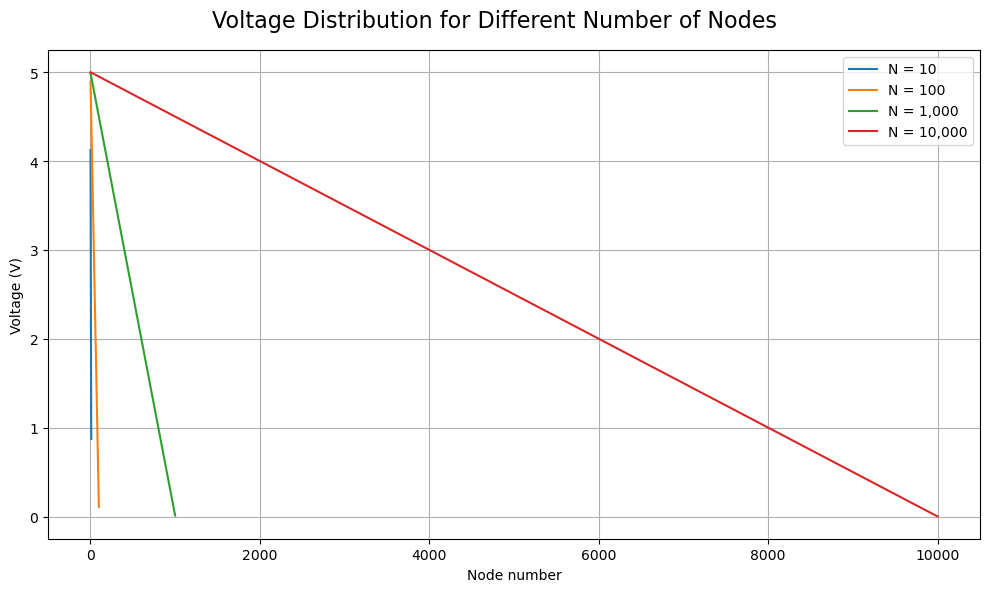

In [5]:
V = {}

for N in [10, 100, 1000, 10000]:

    A_bd = np.zeros((5, N))

    A_bd[2, :] = 4
    A_bd[2, 0] = 3
    A_bd[2, N-1] = 3

    A_bd[1, 1:] = -1
    A_bd[0, 2:] = -1
    A_bd[3, :-1] = -1
    A_bd[4, :-2] = -1

    w_bd = np.zeros(N)
    w_bd[0] = 5
    w_bd[1] = 5

    V[N] = bd.banded(A_bd, w_bd, 2, 2)

# Plot all voltages in one graph
plt.figure(figsize=(10, 6))

for N in [10, 100, 1000, 10000]:
    plt.plot(np.arange(1, N + 1), V[N], label=f"N = {N:,}")

plt.xlabel("Node number")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid()


plt.suptitle('Voltage Distribution for Different Number of Nodes', fontsize=16)
plt.tight_layout()
plt.show()

#### Problem 1 code summary


This code constructs and solves the voltage equations for resistor networks with different numbers of nodes. The banded matrix representation is used for larger systems because it stores only the nonzero diagonals, making the computation more memory-efficient while still using the same matrix structure. The resulting voltages are plotted to compare how the voltage distribution changes as the number of nodes increases.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

ModuleNotFoundError: No module named 'samplePackage'

In [ ]:
sP.createZerosArray(4,5)